# Simple Linear Regression 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
data = pd.read_csv('weight_height_24.csv')

In [7]:
data.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


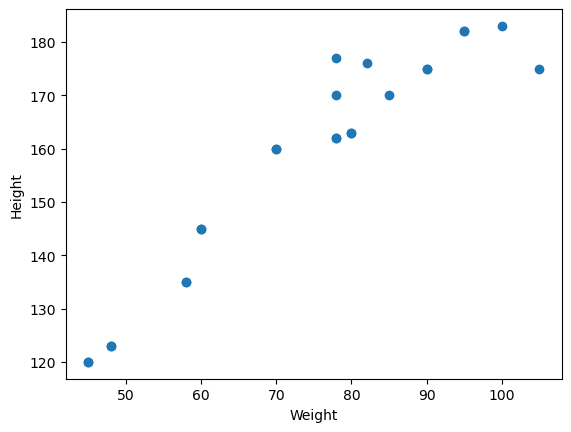

In [9]:
# scatter plot see its diagram
plt.scatter(data['Weight'],data['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [15]:
# divide the independent and dependent dataset
X = data[['Weight']]## independent dataset double [] make it dataframe cause sckit learn except independent feature in dataframe
Y = data['Height']  ## Best Practise to keep it as series
type(X)

pandas.core.frame.DataFrame

In [16]:
## Split the dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size = 0.20, random_state = 42)

In [19]:
## Standarization Dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# How Standarization work ??
When we apply scaler.fit_transform(X_train) it fit calculate mean and standard deviation of data and transform apply the z-score in every data

For X_test data we only apply transform cause in previous data its already calculate the mean and standarization . Its also prevent data lekage

In [20]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

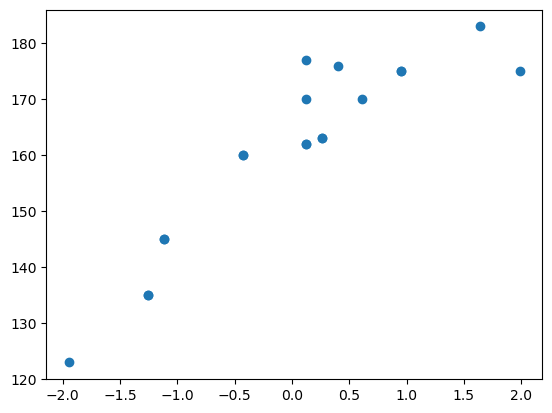

In [22]:
plt.scatter(X_train,y_train)
plt.show()

In [25]:
# Train the Model
from sklearn.linear_model import LinearRegression
linearreg = LinearRegression()
linearreg.fit(X_train,y_train)

LinearRegression()

In [26]:
print('The slope or coef of the data', linearreg.coef_)
print('The intercept of the data', linearreg.intercept_)

The slope or coef of the data [14.86359274]
The intercept of the data 160.73684210526315


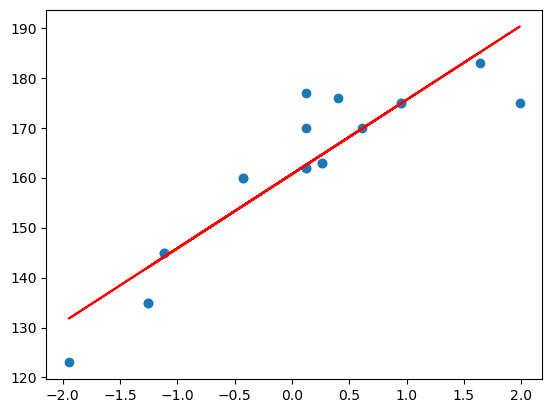

In [30]:
# Now plot the best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,linearreg.predict(X_train), 'r')
plt.show()

# Prediction of Train Data
### predicted_height_output = intercept + coef_(weight)
### y_predict_train = 160.73 + 14,86(weight)

# Prediction of Test Data
### predicted_height_output = intercept + coef_(weight)
### y_predict_test = 160.73 + 14,86(weight)


In [31]:
y_predict_test = linearreg.predict(X_test)

In [32]:
y_predict_test, y_test

(array([180.01096393, 128.72128401, 128.72128401, 131.7986648 ,
        180.01096393]),
 8     182
 16    120
 0     120
 18    123
 11    182
 Name: Height, dtype: int64)

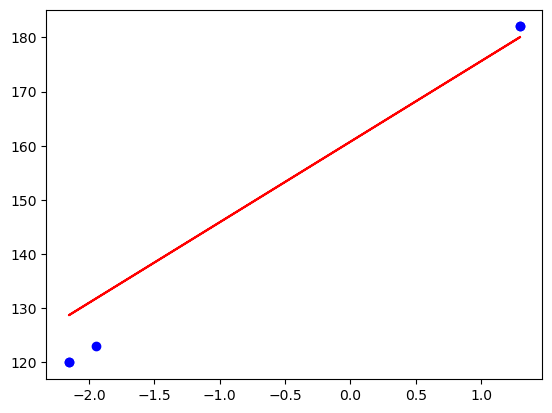

In [35]:
plt.scatter(X_test,y_test, color = 'b')
plt.plot(X_test,y_predict_test, 'r')
plt.show()

In [36]:
X_test

array([[ 1.29673371],
       [-2.15395824],
       [-2.15395824],
       [-1.94691673],
       [ 1.29673371]])

## Performance Metrics
### MSE,MAE,RMSE

## R Square and Adjusted R Square

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [39]:
mse = mean_squared_error(y_test,y_predict_test)
mae = mean_absolute_error(y_test,y_predict_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

47.49012414674037
6.043860991635199
6.891307869101508


In [40]:
## Calculate Accuracy of model by r2_score
from sklearn.metrics import r2_score
score = r2_score(y_test,y_predict_test)
print(score)


0.9468933125931066


In [41]:
# Adjsuted R square
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1] -1)

0.9291910834574755

## Now Predict a random data

In [43]:
scaled_weight = scaler.transform([[80]])
scaled_weight

C:\Users\somra\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.26152613]])

In [45]:
# Now predict the height with this weight
print('Height of 80 kg is ' ,linearreg.predict(scaled_weight))

Height of 80 kg is  [164.62405995]


## Assumption

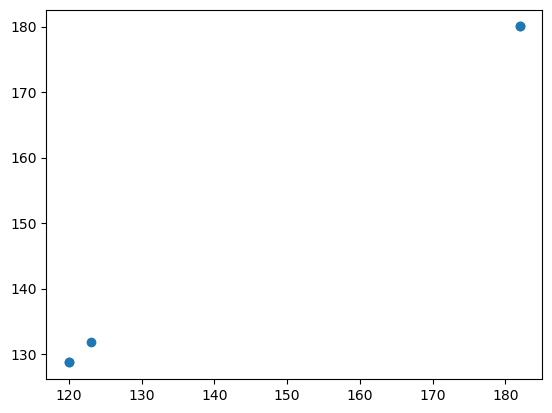

In [46]:
#plot a scatter plot if its linear then i did a great job
plt.scatter(y_test,y_predict_test)
plt.show()

In [47]:
#Residuals
residual = y_test - y_predict_test
residual

8     1.989036
16   -8.721284
0    -8.721284
18   -8.798665
11    1.989036
Name: Height, dtype: float64

C:\Users\somra\AppData\Local\Temp\ipykernel_7796\1093913184.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual,kde = True)


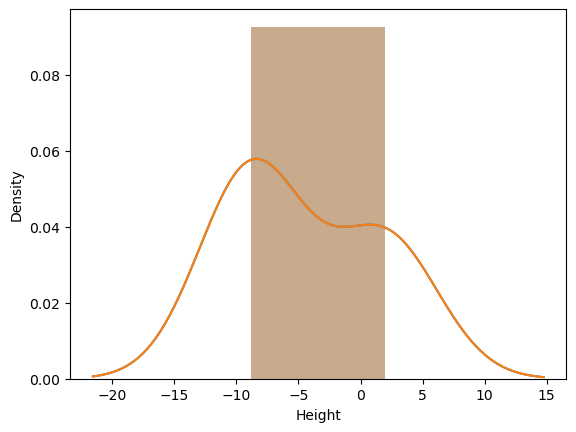

In [54]:
#plot the residual
import seaborn as sns
sns.distplot(residual,kde = True)
plt.show()

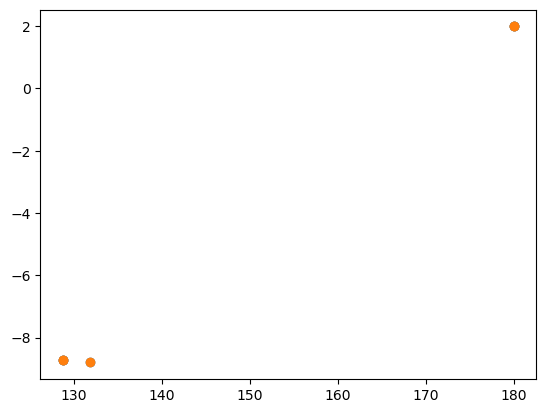

In [56]:
# Scatter Plot with Prediction and residuals
# Uniform Distribution 
plt.scatter(y_predict_test,residual)
plt.show()